In [1]:
import os
import sys

PROJECT_NAME = 'practice-customer-churn-project'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'/content/drive/My Drive/Data Science/PnTDS/04_Projects/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'G:/My Drive/Data Science/PnTDS/04_Projects/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: G:\My Drive\Data Science\PnTDS\04_Projects\practice-customer-churn-project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
path = os.path.join("dataset", "processed", "telco_churn_clean.csv")

df = pd.read_csv(path)

print(f"Data loaded from {path}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Data loaded from dataset\processed\telco_churn_clean.csv
Rows: 7043, Columns: 21


In [9]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [12]:
churn_count = df["Churn"].value_counts()
churn_count

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
churn_percent = df["Churn"].value_counts(normalize=True) * 100
churn_percent

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

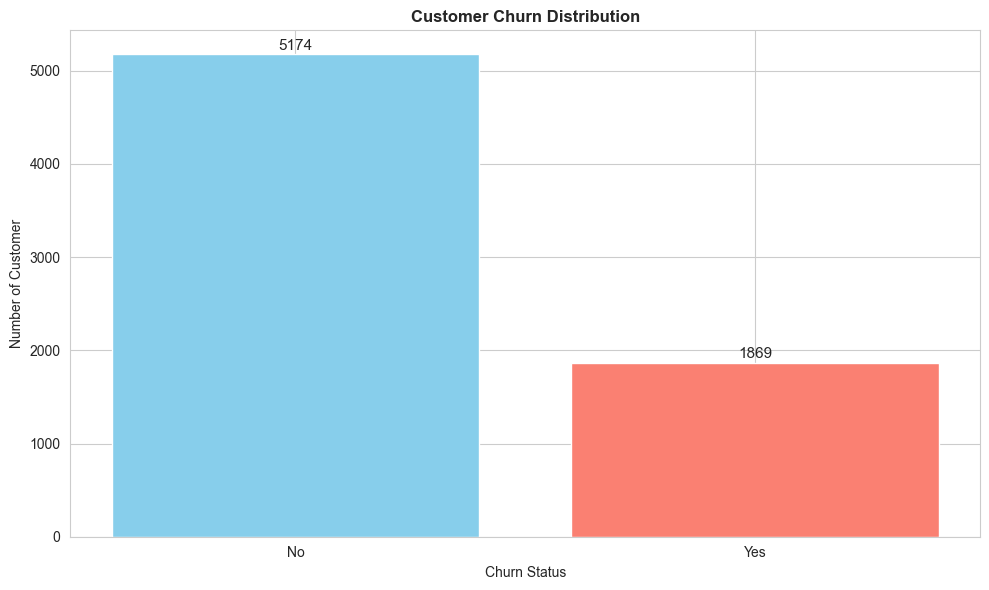

In [39]:
fig, ax = plt.subplots()
colors = ["skyblue", "salmon"]

bars = ax.bar(churn_count.index, churn_count.values, color = colors)
ax.set_title("Customer Churn Distribution", fontweight = "bold")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Number of Customer")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 20, f"{int(height)}", ha = "center", va = "bottom", fontsize = 11)

plt.tight_layout()
plt.savefig(os.path.join("outputs", "visualization", "churn_distribution.png"))

plt.show()